       CLASSIFICATION TASK - TITANIC DATASET
                Register No: 24EU02039

1. FIRST 5 ROWS
--------------------------------------------------
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Dataset Shape: (891, 15)

2. PREPROCESSED DATA
-------------------

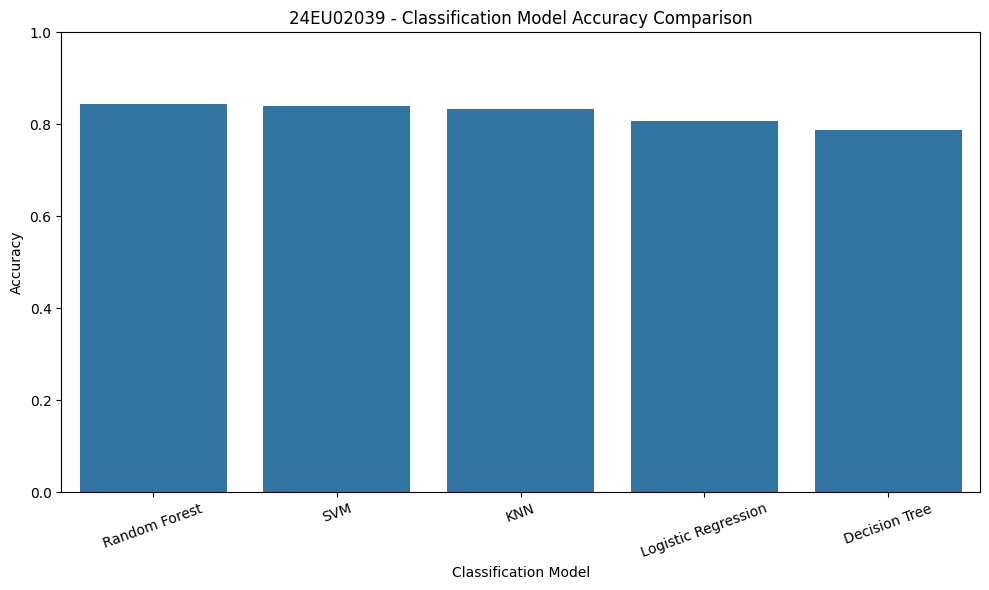

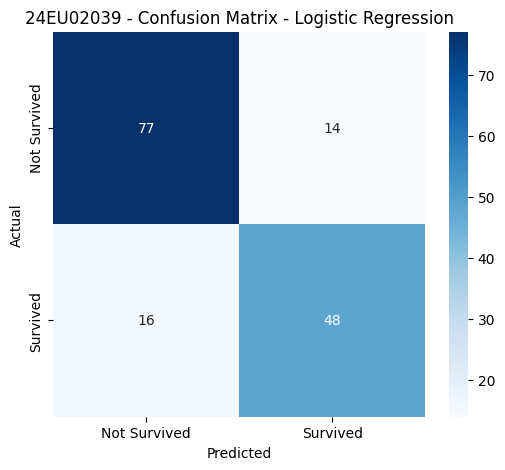

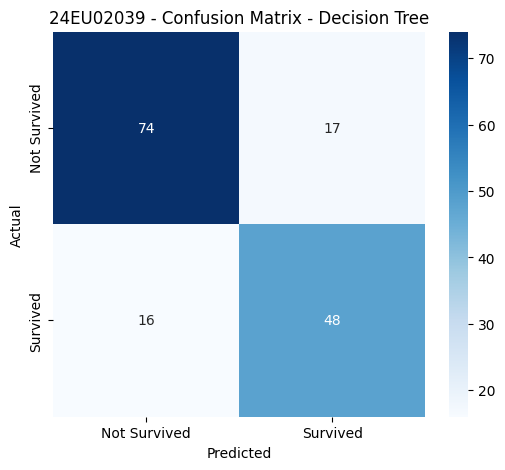

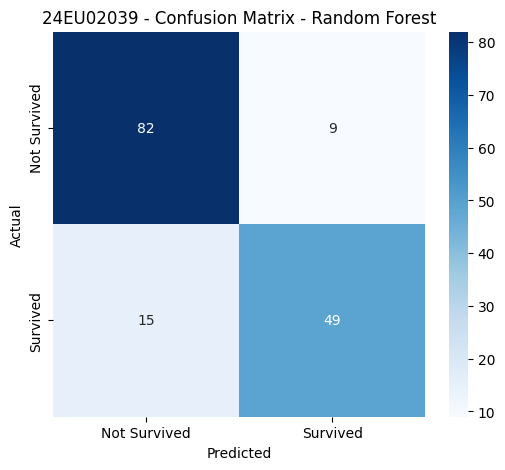

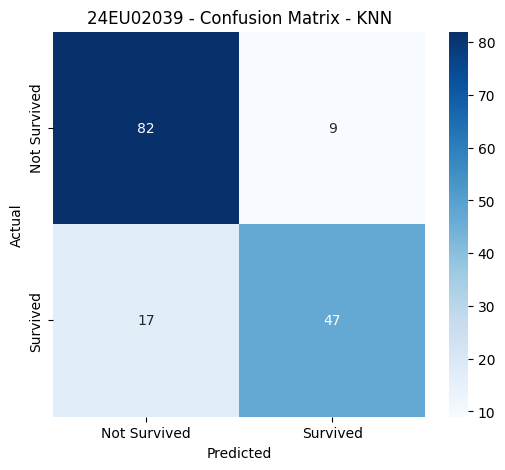

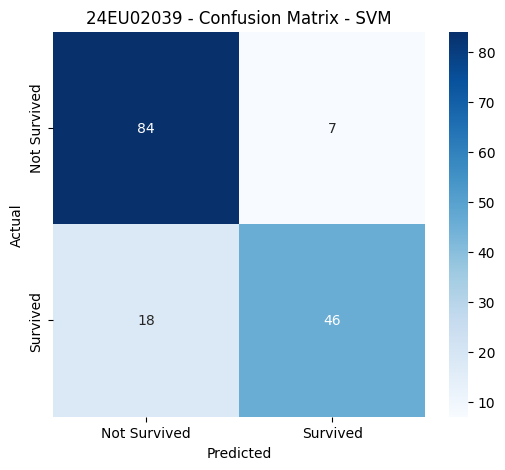



CLASSIFICATION REPORT - Logistic Regression
              precision    recall  f1-score   support

Not Survived       0.83      0.85      0.84        91
    Survived       0.77      0.75      0.76        64

    accuracy                           0.81       155
   macro avg       0.80      0.80      0.80       155
weighted avg       0.81      0.81      0.81       155



CLASSIFICATION REPORT - Decision Tree
              precision    recall  f1-score   support

Not Survived       0.82      0.81      0.82        91
    Survived       0.74      0.75      0.74        64

    accuracy                           0.79       155
   macro avg       0.78      0.78      0.78       155
weighted avg       0.79      0.79      0.79       155



CLASSIFICATION REPORT - Random Forest
              precision    recall  f1-score   support

Not Survived       0.85      0.90      0.87        91
    Survived       0.84      0.77      0.80        64

    accuracy                           0.85       155
  

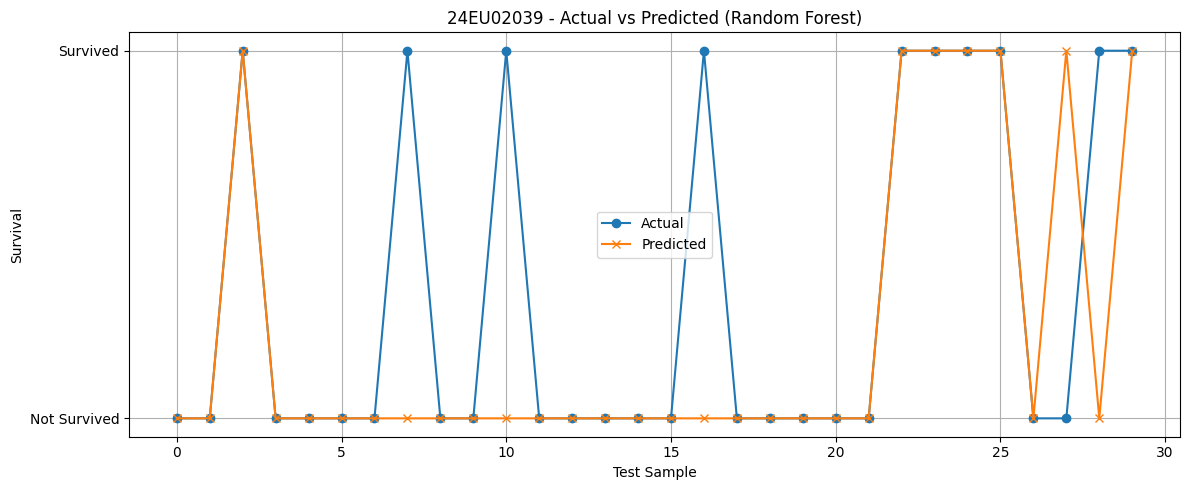



                         CONCLUSION

The Titanic dataset was used for binary classification.

Target:
survived

0 = Not Survived
1 = Survived

Classification algorithms used:
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. K-Nearest Neighbors
5. Support Vector Machine

The data was preprocessed by handling missing values,
encoding categorical variables, creating new features,
removing duplicates and scaling numerical features.

The best performing model was:
Random Forest

Accuracy:
84.52%

       TITANIC CLASSIFICATION COMPLETED
                 24EU02039


In [2]:
# ============================================================
#       CLASSIFICATION TASK - TITANIC DATASET
#       Register Number: 24EU02039
# ============================================================

# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("=" * 70)
print("       CLASSIFICATION TASK - TITANIC DATASET")
print("                Register No: 24EU02039")
print("=" * 70)


# ------------------------------------------------------------
# 1. LOAD DATASET
# ------------------------------------------------------------

df = sns.load_dataset('titanic')

print("\n1. FIRST 5 ROWS")
print("-" * 50)
print(df.head())

print("\nDataset Shape:", df.shape)


# ------------------------------------------------------------
# 2. PREPROCESSING
# ------------------------------------------------------------

# Remove unnecessary columns
df.drop(
    columns=['deck', 'alive', 'embark_town'],
    inplace=True,
    errors='ignore'
)

# Handle missing values
df['age'] = df['age'].fillna(df['age'].median())
df['fare'] = df['fare'].fillna(df['fare'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Create new features
df['family_size'] = df['sibsp'] + df['parch'] + 1
df['is_alone'] = (df['family_size'] == 1).astype(int)

# Encode gender
df['sex'] = df['sex'].map({
    'male': 0,
    'female': 1
})

# One-hot encode 'embarked', 'class', 'who'
df = pd.get_dummies(
    df,
    columns=['embarked', 'class', 'who'],
    drop_first=True,
    dtype=int
)

# Convert boolean columns to int
df['adult_male'] = df['adult_male'].astype(int)
df['alone'] = df['alone'].astype(int)

# Remove duplicate rows
df.drop_duplicates(inplace=True)

print("\n2. PREPROCESSED DATA")
print("-" * 50)
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())


# ------------------------------------------------------------
# 3. FEATURES AND TARGET
# ------------------------------------------------------------

X = df.drop('survived', axis=1)
y = df['survived']

print("\n3. FEATURES")
print("-" * 50)
print(X.columns.tolist())

print("\nTarget: survived")


# ------------------------------------------------------------
# 4. TRAIN-TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n4. TRAIN-TEST SPLIT")
print("-" * 50)
print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])


# ------------------------------------------------------------
# 5. FEATURE SCALING
# ------------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ------------------------------------------------------------
# 6. CREATE CLASSIFICATION MODELS
# ------------------------------------------------------------

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "SVM": SVC(
        kernel='rbf',
        random_state=42
    )
}


# ------------------------------------------------------------
# 7. TRAIN AND EVALUATE MODELS
# ------------------------------------------------------------

results = []
predictions = {}

print("\n")
print("=" * 70)
print("                    MODEL ACCURACY")
print("=" * 70)

for name, model in models.items():

    if name in ["Logistic Regression", "KNN", "SVM"]:

        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

    else:

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy
    })

    predictions[name] = y_pred

    print(
        f"{name:<25}: {accuracy * 100:.2f}%"
    )


# ------------------------------------------------------------
# 8. MODEL COMPARISON
# ------------------------------------------------------------

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='Accuracy',
    ascending=False
)

print("\nMODEL COMPARISON")
print("-" * 50)
print(results_df)


# ------------------------------------------------------------
# 9. GRAPH - MODEL ACCURACY
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x='Model',
    y='Accuracy'
)

plt.title(
    '24EU02039 - Classification Model Accuracy Comparison'
)

plt.xlabel('Classification Model')
plt.ylabel('Accuracy')

plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. CONFUSION MATRICES
# ------------------------------------------------------------

for name, y_pred in predictions.items():

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Not Survived', 'Survived'],
        yticklabels=['Not Survived', 'Survived']
    )

    plt.title(
        f'24EU02039 - Confusion Matrix - {name}'
    )

    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.show()


# ------------------------------------------------------------
# 11. CLASSIFICATION REPORTS
# ------------------------------------------------------------

for name, y_pred in predictions.items():

    print("\n")
    print("=" * 70)
    print(f"CLASSIFICATION REPORT - {name}")
    print("=" * 70)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=[
                'Not Survived',
                'Survived'
            ]
        )
    )


# ------------------------------------------------------------
# 12. BEST MODEL
# ------------------------------------------------------------

best_model_name = results_df.iloc[0]['Model']
best_accuracy = results_df.iloc[0]['Accuracy']

print("\n")
print("=" * 70)
print("                       BEST MODEL")
print("=" * 70)

print("Best Model :", best_model_name)
print("Accuracy   :", f"{best_accuracy * 100:.2f}%")


# ------------------------------------------------------------
# 13. ACTUAL VS PREDICTED
# ------------------------------------------------------------

best_predictions = predictions[best_model_name]

comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': best_predictions
})

print("\nACTUAL VS PREDICTED")
print("-" * 50)
print(comparison.head(20))


# ------------------------------------------------------------
# 14. GRAPH - ACTUAL VS PREDICTED
# ------------------------------------------------------------

sample = comparison.head(30)

plt.figure(figsize=(12, 5))

plt.plot(
    range(len(sample)),
    sample['Actual'],
    marker='o',
    label='Actual'
)

plt.plot(
    range(len(sample)),
    sample['Predicted'],
    marker='x',
    label='Predicted'
)

plt.title(
    f'24EU02039 - Actual vs Predicted ({best_model_name})'
)

plt.xlabel('Test Sample')
plt.ylabel('Survival')

plt.yticks(
    [0, 1],
    ['Not Survived', 'Survived']
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 15. CONCLUSION
# ------------------------------------------------------------

print("\n")
print("=" * 70)
print("                         CONCLUSION")
print("=" * 70)

print(f"""
The Titanic dataset was used for binary classification.

Target:
survived

0 = Not Survived
1 = Survived

Classification algorithms used:
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. K-Nearest Neighbors
5. Support Vector Machine

The data was preprocessed by handling missing values,
encoding categorical variables, creating new features,
removing duplicates and scaling numerical features.

The best performing model was:
{best_model_name}

Accuracy:
{best_accuracy * 100:.2f}%
""")

print("=" * 70)
print("       TITANIC CLASSIFICATION COMPLETED")
print("                 24EU02039")
print("=" * 70)